# Visualisere data

Skal forsøke å vise frem epost-settet.

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import scipy

In [13]:
import gzip
with gzip.open("data/email.edgelist.txt.gz", "rt") as fd:
    G = nx.read_edgelist(fd, create_using=nx.DiGraph())
#
G.remove_edges_from(nx.selfloop_edges(G))
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

Nodes: 57194
Edges: 103083


In [14]:
# 2. Compute the k-core
# k=10 means: Keep only nodes connected to at least 10 other significant nodes.
# Increase 'k' if the graph is still too big.
k = 14
G_core = nx.k_core(G, k=k)
print(f"Nodes: {G_core.number_of_nodes()}")
print(f"Edges: {G_core.number_of_edges()}")

Nodes: 316
Edges: 3998


Koden nedfor tar to minutter å kljøre

Å generere layout tok 11.57 sekunder


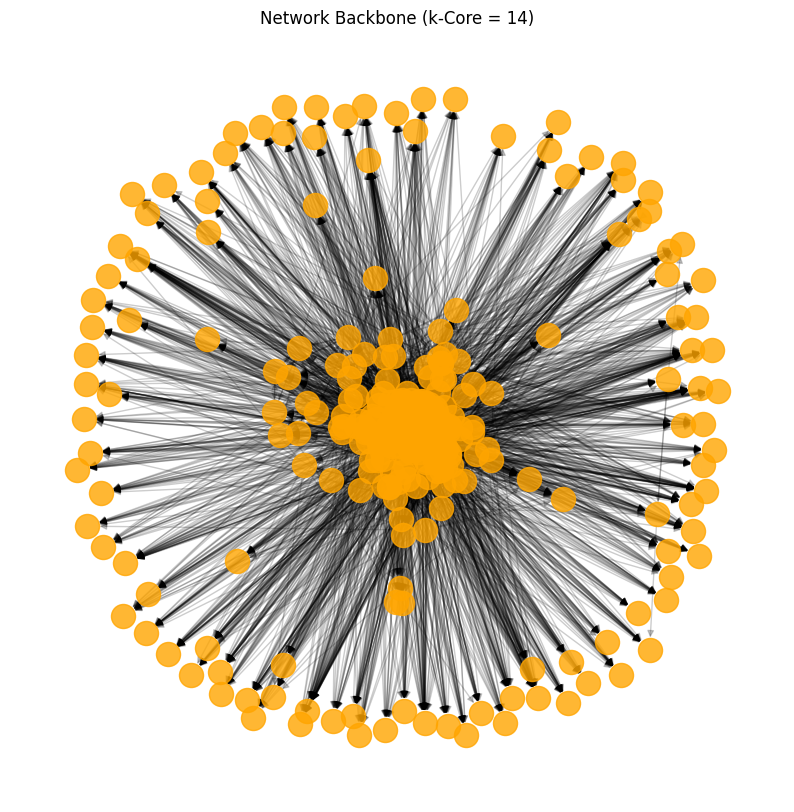

Å tegne layout tok 17.65 sekunder


In [19]:
# 3. Visualize the Core
import time

start = time.time()
pos = nx.spring_layout(G_core, k=0.5, iterations=5000) # Limit iterations!
print(f"Å generere layout tok {time.time()-start:.2f} sekunder")

plt.figure(figsize=(10, 10))
# Size nodes by degree relative to the subgraph
node_sizes = [v * 20 for v in dict(G_core.degree).values()]

pos = nx.spring_layout(G_core)
#nx.draw_networkx_nodes(G_core, pos, node_size=node_sizes, node_color="orange", alpha=0.8)
nx.draw_networkx_nodes(G_core, pos, node_color="orange", alpha=0.8)
#nx.draw(G, pos, with_labels=True, node_color='skyblue', font_size=12, node_size=500)

nx.draw_networkx_edges(G_core, pos, alpha=0.2)
plt.title(f"Network Backbone (k-Core = {k})")
plt.axis('off')
plt.show()
print(f"Å tegne layout tok {time.time()-start:.2f} sekunder")


In [6]:
# 2. Analyze Degrees (Number of Links)
# Get a list of (node, degree) tuples
degree_list = list(G_core.degree())
# Sort them: biggest hubs first
degree_list.sort(key=lambda x: x[1], reverse=True)

# 3. Create "Shells" (Layers) for the Layout
# We will split the nodes into 3 groups based on their connections
total_nodes = len(degree_list)
print(total_nodes)

267


In [7]:
# Top 2% of nodes (The Super Hubs) -> Inner circle
limit_1 = int(total_nodes * 0.02)
# Next 18% of nodes (The Managers) -> Middle circle
limit_2 = int(total_nodes * 0.20)
print(f"Limit 1: {limit_1}")
print(f"Limit 2: {limit_2}")


Limit 1: 5
Limit 2: 53


In [8]:
# Unpack just the node names for the shells
layer_1 = [n for n, d in degree_list[:limit_1]]        # The Core
layer_2 = [n for n, d in degree_list[limit_1:limit_2]] # The Middle
layer_3 = [n for n, d in degree_list[limit_2:]]        # The Periphery
print(len(layer_1), len(layer_2), len(layer_3))

5 48 214


In [9]:
# 4. Compute Layout (INSTANT)
# We pass the list of layers. NetworkX arranges them in concentric circles.
pos = nx.shell_layout(G_core, nlist=[layer_1, layer_2, layer_3])

In [10]:
# 5. Define Visual Style based on Degree
# Extract degrees to a simple list for sizing/coloring
degrees = dict(G_core.degree())
# Size: Make hubs huge, leaves tiny. 
# We add a base size (5) so tiny nodes are still visible.
node_sizes = [degrees[n] * 6 + 5 for n in G_core.nodes()]
# Color: Map degree to a color intensity (optional, but helpful)
node_colors = [degrees[n] for n in G_core.nodes()]

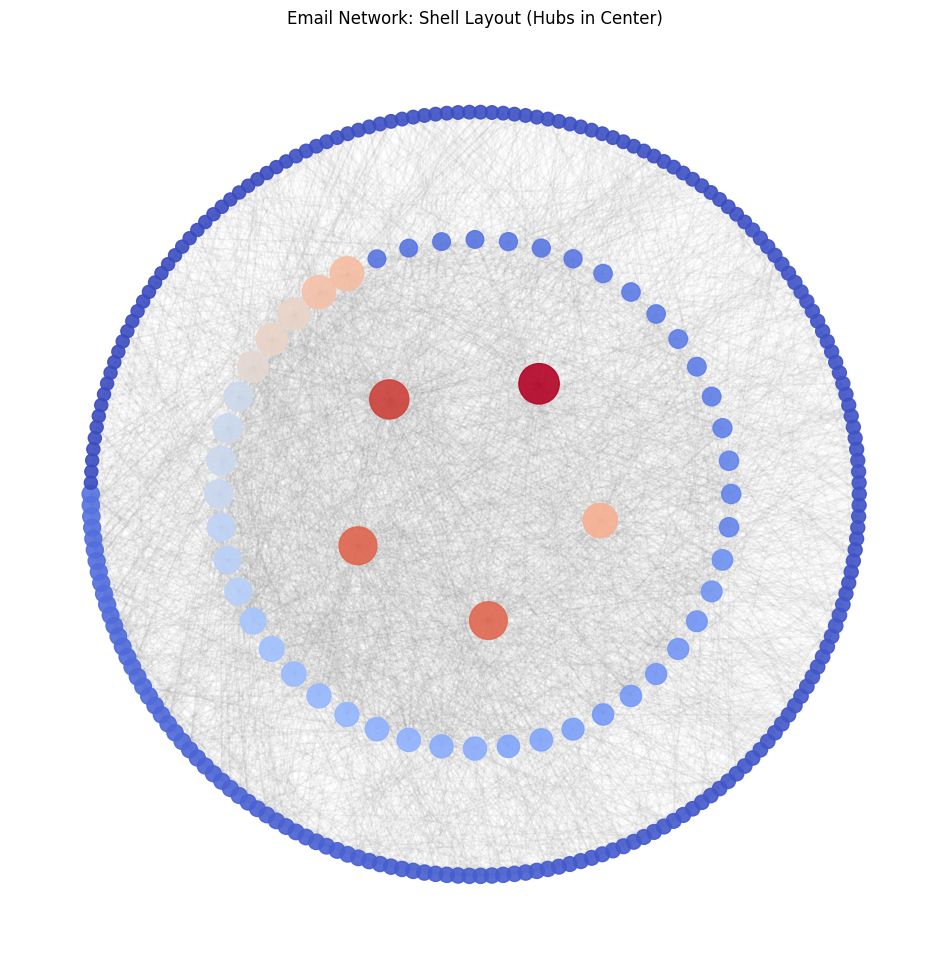

In [11]:
# 6. Draw
plt.figure(figsize=(12, 12))

# Draw Nodes
nx.draw_networkx_nodes(G_core, pos, 
                       node_size=node_sizes, 
                       node_color=node_colors, 
                       cmap=plt.cm.coolwarm, # Red = Hub, Blue = Leaf
                       alpha=0.9)
# Draw Edges (Make them very faint!)
nx.draw_networkx_edges(G_core, pos, alpha=0.05, edge_color="gray")

plt.title("Email Network: Shell Layout (Hubs in Center)")
plt.axis('off')
plt.show()

In [12]:
from ipysigma import Sigma
import math

log_degree = {}
for node, deg in G.degree():
    log_degree[node] = math.log(deg + 1) 
#    
Sigma(
    G, 
    node_size=log_degree,
    node_color=log_degree,
    node_color_gradient="Plasma",
    node_size_range=(1, 30),
    default_edge_type="curve"
)

Sigma(nx.Graph with 57,194 nodes and 92,442 edges)